In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look nicer
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
# Load the main match results file
df = pd.read_csv("../data/raw/results.csv")

# Check how many rows and columns we have
print(f"Dataset shape: {df.shape}")
print(f"That's {df.shape[0]:,} matches and {df.shape[1]} columns")

Dataset shape: (49287, 9)
That's 49,287 matches and 9 columns


In [5]:
# Show the first 5 rows
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [6]:
# What columns do we have?
print(df.columns.tolist())
print()

# What data types are they?
print(df.dtypes)

['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

date              str
home_team         str
away_team         str
home_score    float64
away_score    float64
tournament        str
city              str
country           str
neutral          bool
dtype: object


In [7]:
# Are there any missing values?
df.isnull().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [8]:
# Show the first 5 rows
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [9]:
# Show the 10 most recent matches
df.tail(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49277,2026-06-26,Cape Verde,Saudi Arabia,NaN,NaN,FIFA World Cup,Houston,United States,True
49278,2026-06-26,Uruguay,Spain,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True
49279,2026-06-26,Norway,France,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49280,2026-06-26,Senegal,Iraq,NaN,NaN,FIFA World Cup,Toronto,Canada,True
49281,2026-06-27,Algeria,Austria,NaN,NaN,FIFA World Cup,Kansas City,United States,True
49282,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49283,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49284,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49285,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49286,2026-06-27,Croatia,Ghana,NaN,NaN,FIFA World Cup,Philadelphia,United States,True


In [10]:
# Convert date column from text to actual datetime
df["date"] = pd.to_datetime(df["date"])

# Extract the year into its own column (useful later)
df["year"] = df["date"].dt.year

# Check it worked
print(df["date"].dtype)
print(df[["date", "year"]].head())

datetime64[us]
        date  year
0 1872-11-30  1872
1 1873-03-08  1873
2 1874-03-07  1874
3 1875-03-06  1875
4 1876-03-04  1876


In [11]:
# How many different tournament types exist?
print(f"Number of unique tournaments: {df['tournament'].nunique()}")

# Top 10 most common tournament types
df["tournament"].value_counts().head(10)

Number of unique tournaments: 193


tournament
Friendly                                18252
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
Name: count, dtype: int64

In [12]:
# Filter to only FIFA World Cup matches (the tournament itself, not qualifiers)
wc_matches = df[df["tournament"] == "FIFA World Cup"].copy()

print(f"Total World Cup matches: {len(wc_matches)}")
print(f"Years covered: {wc_matches['year'].min()} to {wc_matches['year'].max()}")
wc_matches.head()

Total World Cup matches: 1036
Years covered: 1930 to 2026


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
1486,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True,1930
1487,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True,1930
1488,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True,1930
1489,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True,1930
1490,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True,1930


In [13]:
# Calculate total goals per match
df["total_goals"] = df["home_score"] + df["away_score"]

# Quick statistical summary
print(df["total_goals"].describe())
print(f"\nMost common scoreline (total goals): {df['total_goals'].mode()[0]}")

count    49215.000000
mean         2.938494
std          2.092775
min          0.000000
25%          1.000000
50%          3.000000
75%          4.000000
max         31.000000
Name: total_goals, dtype: float64

Most common scoreline (total goals): 2.0


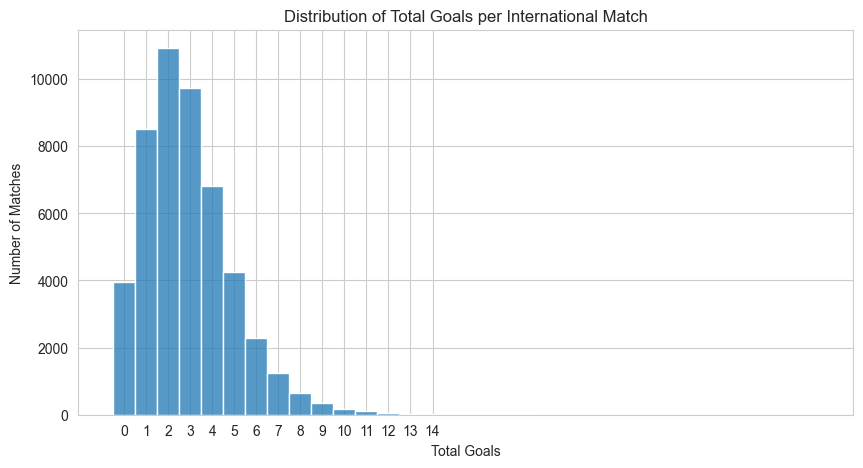

In [14]:
# Histogram of total goals per match
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="total_goals", bins=range(0, 15), discrete=True)
plt.title("Distribution of Total Goals per International Match")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")
plt.xticks(range(0, 15))
plt.show()

In [15]:
# Compare only NON-neutral venue matches (where home/away truly means something)
not_neutral = df[df["neutral"] == False]

home_wins = (not_neutral["home_score"] > not_neutral["away_score"]).sum()
draws = (not_neutral["home_score"] == not_neutral["away_score"]).sum()
away_wins = (not_neutral["home_score"] < not_neutral["away_score"]).sum()
total = len(not_neutral)

print(f"Home wins: {home_wins:,} ({home_wins/total*100:.1f}%)")
print(f"Draws:     {draws:,} ({draws/total*100:.1f}%)")
print(f"Away wins: {away_wins:,} ({away_wins/total*100:.1f}%)")

Home wins: 18,379 (50.7%)
Draws:     8,285 (22.9%)
Away wins: 9,575 (26.4%)


In [16]:
# Count appearances as home OR away
all_appearances = pd.concat([df["home_team"], df["away_team"]])
top_teams = all_appearances.value_counts().head(15)

print("Top 15 most active international teams:")
print(top_teams)

Top 15 most active international teams:
Sweden         1102
England        1091
Argentina      1067
Brazil         1060
Germany        1032
South Korea    1008
Hungary        1004
Mexico         1003
Uruguay         971
France          936
Italy           891
Poland          890
Switzerland     885
Netherlands     880
Norway          873
Name: count, dtype: int64


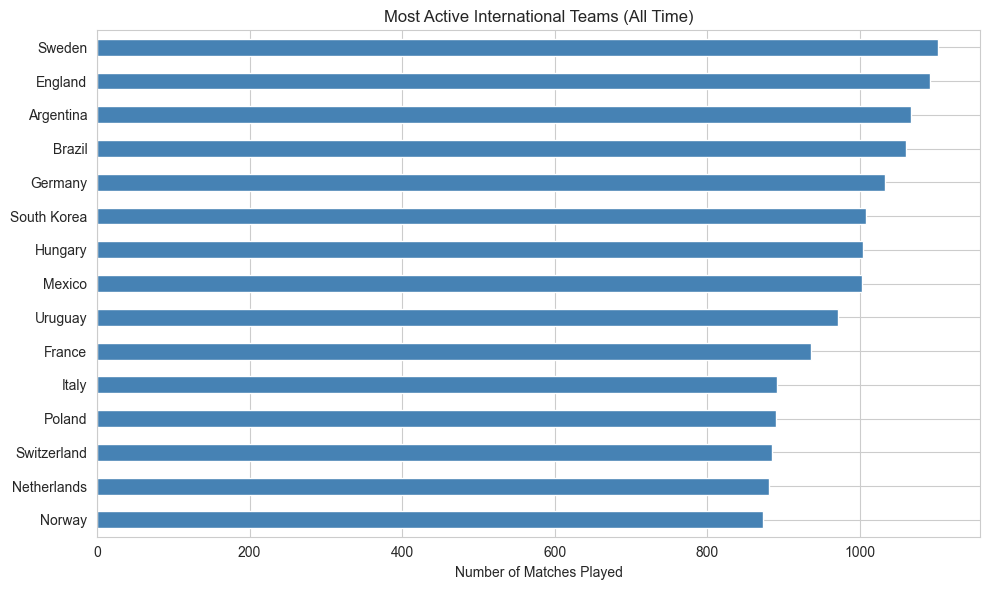

In [17]:
plt.figure(figsize=(10, 6))
top_teams.plot(kind="barh", color="steelblue")
plt.title("Most Active International Teams (All Time)")
plt.xlabel("Number of Matches Played")
plt.gca().invert_yaxis()  # flip so #1 is at the top
plt.tight_layout()
plt.show()